<img style="float: left; padding: 20px 50px 20px 50px; width: 100px;" src="Kalyani_logo_white.png" alt="Kalyani" />
<h1 style="display: inline-block; margin-left: 20px;">Autonomous Annotation Application</h1>

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
HOME = os.getcwd()

In [ ]:
%%capture
%cd {HOME} 
%cd ..
# !pip install -e . -q
!python3 setup.py build_ext --inplace

/home/kalyani-robotics/segment-anything-2/notebooks
/home/kalyani-robotics/segment-anything-2


In [3]:
# !pip install moviepy

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.3/388.3 KB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.4/315.4 KB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 9.4 MB/s eta 0:00:00m eta 0:00:010:00:01m
  Created wheel for moviepy: filename=moviepy-1.0.3-py3-none-any.whl size=110747 sha256=24494d920d385217d7f6a21686c57df9c43288c6f2df14985578e0f061e98697
  Stored in directory: /tmp/pip-ephem-wheel-cache-cfrp6y_2/wheels/96/32/2d/e10123bd88fbfc02fed53cc18c80a171d3c87479ed845fa7c1
Successfully built moviepy


In [2]:
# !pip install -q supervision[assets] jupyter_bbox_widget
# !mkdir -p {HOME}/checkpoints
# !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt -P {HOME}/checkpoints
# !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt -P {HOME}/checkpoints
# !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt -P {HOME}/checkpoints
# !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints
# pip install --upgrade supervision

In [12]:
import cv2
import torch
import base64

import numpy as np
import supervision as sv

from pathlib import Path
from supervision.assets import download_assets, VideoAssets
from sam2.build_sam import build_sam2_video_predictor

IS_COLAB = False

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

In [13]:
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [14]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = "checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"

sam2_model = build_sam2_video_predictor(CONFIG, CHECKPOINT)

In [1]:
# put the list of your fixed classes if planning to annotate for >10 classes
OUR_CLASSES = ["amphitheatre", "automation-setup", "backpack", "battery", "bean-bag", "book", "bottle", "chair", "coffee-machine", "coffee-table", "couch", "cup", "cupboards", "screen", "door", "dustbin", "extender", "headphones", "human", "identity-card", "joystick", "keyboard", "keys", "laptop", "light-bulb", "mechanum", "monitor", "mouse", "nvidia-jetson", "office-chair", "office-desk", "oscilloscope", "pen", "plant", "printer", "robotic-arm", "server", "sleeping-pod", "smartphone", "spectacles", "stairs", "switch-board", "tablet", "tree", "vending-machine", "vr-headset", "watch", "white-board", "wifi-router", "work-pod"]

# choose a custom frame index to start from if not happy with annotations
FRAME_IDX = 0

In [4]:
from io import BytesIO
import os
import ipywidgets as widgets
from IPython.display import display, HTML
import moviepy.video.io.ImageSequenceClip
import re


# Create file upload widget
upload_widget = widgets.FileUpload(
    accept='.mp4, .mov, .avi',  # Restrict file types
    multiple=False  # Only allow single file upload
)


output = widgets.Output()

display(upload_widget, output)

def on_value_change(change):
    with output:
        vid_name = change['new'][0].name
        video_path = "video/" + vid_name  # Get the name of the uploaded file
        
        with open(video_path, "wb") as fp:
            fp.write(change['new'][0].content)
        
        print(f"Video uploaded and saved as {vid_name}")

        HOME = os.getcwd()
        SOURCE_VIDEO = video_path
        SCALE_FACTOR = 0.5

        SOURCE_FRAMES = Path(HOME) / "train" / Path(SOURCE_VIDEO).stem
        SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)
        
        frames_generator = sv.get_video_frames_generator(SOURCE_VIDEO)
        images_sink = sv.ImageSink(
            target_dir_path=SOURCE_FRAMES.as_posix(),
            overwrite=True,
            image_name_pattern="{:05d}.jpeg"
        )
            
        with images_sink:
            for frame in frames_generator:
                frame = sv.scale_image(frame, SCALE_FACTOR)
                images_sink.save_image(frame)
        
        TARGET_VIDEO = Path(HOME) / "video" / f"{Path(SOURCE_VIDEO).stem}-result.mp4"
        SOURCE_FRAME_PATHS = sorted(sv.list_files_with_extensions(SOURCE_FRAMES.as_posix(), extensions=["jpeg"]))

        inference_state = sam2_model.init_state(video_path=SOURCE_FRAMES.as_posix())

        def encode_image(filepath):
            with open(filepath, 'rb') as f:
                image_bytes = f.read()
            encoded = str(base64.b64encode(image_bytes), 'utf-8')
            return "data:image/jpg;base64,"+encoded

        def hex_to_rgb(value):
            # Remove the hash at the start if it's there
            value = value.lstrip('#')
            lv = len(value)
            # Convert to RGB tuple
            r, g, b = (int(value[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
            return (b, g, r)

        # Empty list of objects
        OBJECTS = []
        
        # Function to handle input
        def update_objects(change):
            with output2:
                # Get the input value, replace spaces with dashes, and split by commas
                user_input = text_box.value
                new_objects = [obj.strip().replace(' ', '-') for obj in user_input.split(',') if obj.strip()]
                
                OBJECTS.extend(new_objects)
        
                print("Updated class list:", OBJECTS)

                FRAME_PATH = Path(SOURCE_FRAMES) / f"{FRAME_IDX:05d}.jpeg"


                def annotate(change):
                    with output3:
                        boxes = widget.bboxes
                        for object_id, label in enumerate(OBJECTS, start=1):
                            boxes = [box for box in widget.bboxes if box['label'] == label]

                            if len(boxes) == 0:
                                continue
    
                            points = np.array([
                                [
                                    box['x'],
                                    box['y']
                                ] for box in boxes
                            ], dtype=np.float32)
                            labels = np.ones(len(points))
                        
                            _, object_ids, mask_logits = sam2_model.add_new_points(
                                inference_state=inference_state,
                                frame_idx=FRAME_IDX,
                                obj_id=object_id,
                                points=points,
                                labels=labels,
                            )


                        def on_no_clicked(change):
                            with output_confirm:
                                video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
                                video_info.width = int(video_info.width * SCALE_FACTOR)
                                video_info.height = int(video_info.height * SCALE_FACTOR)
        
                                COLORS = ['#ffffff', 
                                          "#1f77b4",
                                          "#ff7f0e",
                                          "#2ca02c",
                                          "#d62728",
                                          "#9467bd",
                                          "#8c564b",
                                          "#e377c2",
                                          "#7f7f7f",
                                          "#bcbd22",
                                          "#17becf"]
                                
                                mask_annotator = sv.MaskAnnotator(
                                    color=sv.ColorPalette.from_hex(COLORS),
                                    color_lookup=sv.ColorLookup.CLASS)
                    
                                frame_sample = []
        
                                output_dir = Path(HOME) / "label" / Path(SOURCE_VIDEO).stem
                                an_output_dir = Path(HOME) / "annotate" / Path(SOURCE_VIDEO).stem
                                os.makedirs(output_dir, exist_ok=True)
                                os.makedirs(an_output_dir, exist_ok=True)
        
                                with sv.VideoSink(TARGET_VIDEO.as_posix(), video_info=video_info) as sink:
                                    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
                                        frame_path = SOURCE_FRAME_PATHS[frame_idx]
                                        frame = cv2.imread(str(frame_path))
                                        masks = (mask_logits > 0.0).cpu().numpy()
                                        masks = np.squeeze(masks).astype(bool)                        
                                        detections = sv.Detections(
                                            xyxy=sv.mask_to_xyxy(masks=masks),
                                            mask=masks,
                                            class_id=np.array(object_ids)
                                        )
        
                                        annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=detections)
            
                                        for object_id, (x1, y1, x2, y2) in zip(object_ids, detections.xyxy):
                                            if all(coord == 0 for coord in (x1, y1, x2, y2)):
                                                continue
                                            class_name = OBJECTS[object_id-1] if object_id <= len(OBJECTS) else "Unknown"
                                            label = f"{class_name}"
                                            color = hex_to_rgb(COLORS[object_id])
                                            cv2.putText(annotated_frame, label, (int(x1), int(y1 + 15)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 1)
                                            cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
    
                                        # sink.write_frame(annotated_frame)
        
                                        output_filename = f"{frame_idx:05d}.png" 
                                        output_path = os.path.join(an_output_dir, output_filename)
                
                                        # Save the annotated frame image
                                        cv2.imwrite(output_path, annotated_frame)
        
                                        bbox_file_path = os.path.join(output_dir, f"{frame_idx:05d}.txt")  # Using zero-padded frame index
                                        with open(bbox_file_path, 'w') as f:
                                            for i in range(len(detections.class_id)):
                                                class_id = detections.class_id[i]
                                                # For using the OUR_CLASSES code
                                                class_name = OBJECTS[class_id-1]
                                                class_name = re.sub(r'\d+', '', class_name)
                                                if class_name in OUR_CLASSES:
                                                    class_id = OUR_CLASSES.index(class_name)
                                                else:
                                                    continue
                                                xyxy = detections.xyxy[i]  # Get the bounding box coordinates
                                                x1, y1, x2, y2 = xyxy
                                                if all(coord == 0 for coord in (x1, y1, x2, y2)):
                                                    continue
                                                # Convert to YOLO format
                                                x_center = (x1 + x2) / 2 / frame.shape[1]  # Normalize x_center
                                                y_center = (y1 + y2) / 2 / frame.shape[0]  # Normalize y_center
                                                width = (x2 - x1) / frame.shape[1]  # Normalize width
                                                height = (y2 - y1) / frame.shape[0]  # Normalize height
                            
                                                # Write to the file
                                                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
        
                                        if frame_idx % video_info.fps == 0:
                                            frame_sample.append(annotated_frame)
        
                                image_files = [os.path.join(an_output_dir,img) for img in sorted(os.listdir(an_output_dir))]
                                clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(image_files, fps=30)
                                clip.write_videofile(f"{TARGET_VIDEO}")
        
                                # print("Segmentation is complete.")
                                # print(f"YOLO bounding box annotations are saved at {output_dir}")
        
                                display(HTML('<h2 align="center">Sample of Segmented Results</h2>'))
                                
                                sv.plot_images_grid(
                                    images=frame_sample[:6:2],
                                    grid_size=(1, 3)
                                )
    
                        def on_yes_clicked(change):
                            with output_confirm:
                                widget = BBoxWidget(classes=OBJECTS)
                                widget.image = encode_image(FRAME_PATH)
                                widget.hide_buttons = True

                                def annotate2(change):
                                    with output4:
                                        boxes = widget.bboxes
                                        for object_id, label in enumerate(OBJECTS, start=1):
                                            boxes = [box for box in widget.bboxes if box['label'] == label]
    
                                            if len(boxes) == 0:
                                                continue
        
                                            points = np.array([
                                                [
                                                    box['x'],
                                                    box['y']
                                                ] for box in boxes
                                            ], dtype=np.float32)
                                            labels = np.zeros(len(points))
                            
                                            _, object_ids, mask_logits = sam2_model.add_new_points(
                                                inference_state=inference_state,
                                                frame_idx=FRAME_IDX,
                                                obj_id=object_id,
                                                points=points,
                                                labels=labels,
                                            )
    
                                        on_no_clicked(True)
                                        
                                    
                                continue_button = widgets.Button(description='Continue', style={'button_color' : 'green'})
        
                                output4 = widgets.Output()
    
                                display(widget, continue_button, output4)
    
                                continue_button.on_click(annotate2)

                        confirmation_box = widgets.VBox([
                            widgets.Label("Do you want to add negative areas?"),
                            widgets.HBox([
                                widgets.Button(description='Yes', style={'button_color': 'green'}),
                                widgets.Button(description='No', style={'button_color': 'red'})
                            ])
                        ])

                        output_confirm = widgets.Output()

                        display(confirmation_box, output_confirm)
        
                        confirmation_box.children[1].children[0].on_click(on_yes_clicked)
                        confirmation_box.children[1].children[1].on_click(on_no_clicked)
                        

                widget = BBoxWidget(classes=OBJECTS)
                widget.image = encode_image(FRAME_PATH)
                widget.hide_buttons = True

                continue_button = widgets.Button(description='Continue', style={'button_color' : 'green'})

                output3 = widgets.Output()

                display(widget, continue_button, output3)

                continue_button.on_click(annotate)

        text_box = widgets.Text(
            description='Enter classes:',
            placeholder='comma-separated values (minimum 2)',
            layout=widgets.Layout(width='auto'),
            style= {'description_width': 'initial'}
        )

        update_button = widgets.Button(description='Add Classes', style={'button_color' : 'green'})

        output2 = widgets.Output()

        display(text_box, update_button, output2)

        update_button.on_click(update_objects)


upload_widget.observe(on_value_change, names='value')

SyntaxError: unterminated string literal (detected at line 191) (901719231.py, line 191)

In [24]:
# HOME = os.getcwd()
# SOURCE_VIDEO = video_path

In [25]:
# SCALE_FACTOR = 0.5
# START_IDX = 100
# END_IDX = 300

In [26]:
# SOURCE_FRAMES = Path(HOME) / Path(SOURCE_VIDEO).stem
# SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

# frames_generator = sv.get_video_frames_generator(SOURCE_VIDEO)
# images_sink = sv.ImageSink(
#     target_dir_path=SOURCE_FRAMES.as_posix(),
#     overwrite=True,
#     image_name_pattern="{:05d}.jpeg"
# )

# with images_sink:
#     for frame in frames_generator:
#         frame = sv.scale_image(frame, SCALE_FACTOR)
#         images_sink.save_image(frame)

# TARGET_VIDEO = Path(HOME) / "video" / f"{Path(SOURCE_VIDEO).stem}-result.mp4"
# SOURCE_FRAME_PATHS = sorted(sv.list_files_with_extensions(SOURCE_FRAMES.as_posix(), extensions=["jpeg"]))

In [27]:
# inference_state = sam2_model.init_state(video_path=SOURCE_FRAMES.as_posix())

frame loading (JPEG): 100%|███████████████████| 325/325 [00:06<00:00, 48.66it/s]


In [28]:
# sam2_model.reset_state(inference_state)

In [29]:
# def encode_image(filepath):
#     with open(filepath, 'rb') as f:
#         image_bytes = f.read()
#     encoded = str(base64.b64encode(image_bytes), 'utf-8')
#     return "data:image/jpg;base64,"+encoded

In [30]:
# # Empty list of objects
# OBJECTS = []

# # Function to handle input
# def update_objects(change):
#     # Get the input value, replace spaces with dashes, and split by commas
#     user_input = text_box.value
#     new_objects = [obj.strip().replace(' ', '-') for obj in user_input.split(',') if obj.strip()]
    
#     # Update the OBJECTS list
#     OBJECTS.extend(new_objects)
    
#     # Display the updated list
#     print("Updated objects:", OBJECTS)

# # Create a text box for input
# text_box = widgets.Text(
#     description='Enter objects:',
#     placeholder='comma-separated values',
#     layout=widgets.Layout(width='auto'),
#     style= {'description_width': 'initial'}
# )

# # Create a button to submit
# submit_button = widgets.Button(description='Add Objects',
#                               style={'button_color': 'lightgreen'})

# # Link the button click event to the update function
# submit_button.on_click(lambda b: update_objects(None))

In [31]:
# display(text_box, submit_button)

Text(value='', description='Enter objects:', layout=Layout(width='auto'), placeholder='comma-separated values'…

Button(description='Add Objects', style=ButtonStyle(button_color='lightgreen'))

In [32]:
# FRAME_IDX = 0
# FRAME_PATH = Path(SOURCE_FRAMES) / f"{FRAME_IDX:05d}.jpeg"

# widget = BBoxWidget(classes=OBJECTS)
# widget.image = encode_image(FRAME_PATH)
# widget

BBoxWidget(classes=['specs', 'chair'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b…

In [33]:
# default_box = [
#     {'x': 705, 'y': 302, 'width': 0, 'height': 0, 'label': 'ball'},
#     {'x': 587, 'y': 300, 'width': 0, 'height': 0, 'label': 'player-1'},
#     {'x': 753, 'y': 267, 'width': 0, 'height': 0, 'label': 'player-2'}
# ]

# boxes = widget.bboxes if widget.bboxes else default_box

# for object_id, label in enumerate(OBJECTS, start=1):
#     boxes = [box for box in widget.bboxes if box['label'] == label]

#     if len(boxes) == 0:
#         continue

#     points = np.array([
#         [
#             box['x'],
#             box['y']
#         ] for box in boxes
#     ], dtype=np.float32)
#     labels = np.ones(len(points))

#     _, object_ids, mask_logits = sam2_model.add_new_points(
#         inference_state=inference_state,
#         frame_idx=FRAME_IDX,
#         obj_id=object_id,
#         points=points,
#         labels=labels,
#     )

In [34]:
# widget = BBoxWidget(classes=OBJECTS)
# widget.image = encode_image(FRAME_PATH)
# widget

BBoxWidget(classes=['specs', 'chair'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b…

In [35]:
# boxes = widget.bboxes if widget.bboxes else default_box

# for object_id, label in enumerate(OBJECTS, start=1):
#     boxes = [box for box in widget.bboxes if box['label'] == label]

#     if len(boxes) == 0:
#         continue

#     points = np.array([
#         [
#             box['x'],
#             box['y']
#         ] for box in boxes
#     ], dtype=np.float32)
#     labels = np.zeros(len(points))

#     _, object_ids, mask_logits = sam2_model.add_new_points(
#         inference_state=inference_state,
#         frame_idx=FRAME_IDX,
#         obj_id=object_id,
#         points=points,
#         labels=labels,
#     )

In [36]:
# video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
# video_info.width = int(video_info.width * SCALE_FACTOR)
# video_info.height = int(video_info.height * SCALE_FACTOR)

# COLORS = ['#FF1493', '#00BFFF', '#FFD700']
# mask_annotator = sv.MaskAnnotator(
#     color=sv.ColorPalette.from_hex(COLORS),
#     color_lookup=sv.ColorLookup.CLASS)

# frame_sample = []

# with sv.VideoSink(TARGET_VIDEO.as_posix(), video_info=video_info) as sink:
#     for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
#         frame_path = SOURCE_FRAME_PATHS[frame_idx]
#         frame = cv2.imread(str(frame_path))
#         masks = (mask_logits > 0.0).cpu().numpy()
#         masks = np.squeeze(masks).astype(bool)

#         detections = sv.Detections(
#             xyxy=sv.mask_to_xyxy(masks=masks),
#             mask=masks,
#             class_id=np.array(object_ids)
#         )

#         annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=detections)

#         sink.write_frame(annotated_frame)
#         if frame_idx % video_info.fps == 0:
#             frame_sample.append(annotated_frame)

propagate in video: 100%|█████████████████████| 325/325 [00:18<00:00, 17.31it/s]


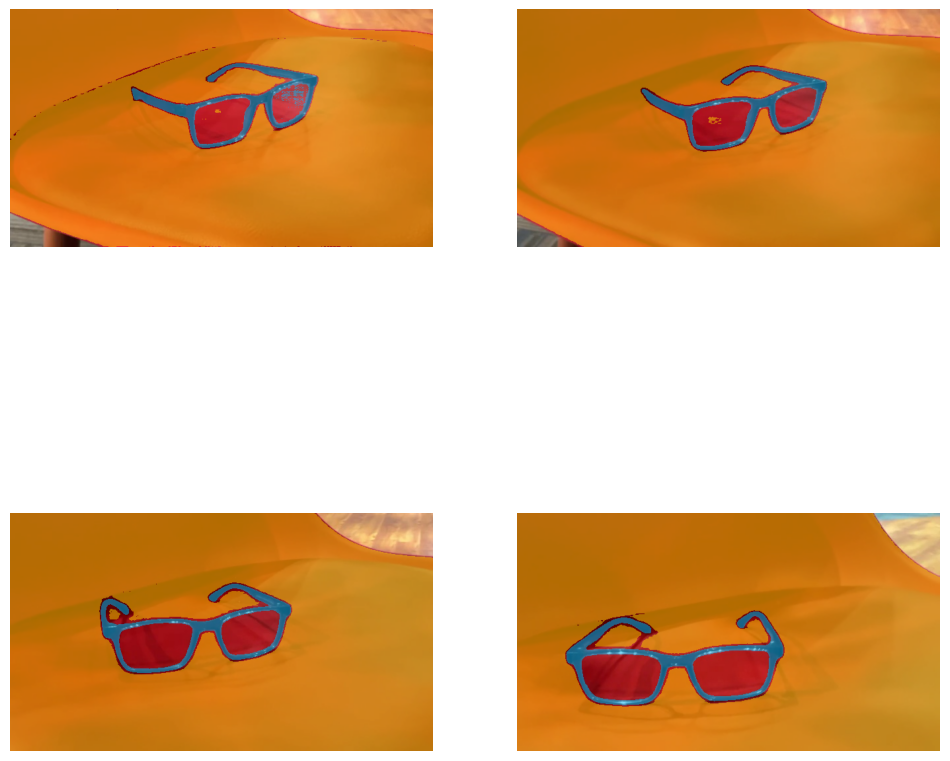

In [37]:
# sv.plot_images_grid(
#     images=frame_sample[:4],
#     grid_size=(2, 2)
# )